## **Regresión lineal en dataset "Forest Fires"**

### **Problema**

Se tiene un dataset de registros de incendios del 2008 en Portugal, donde se busca predecir el área quemada resultante de los incendios en la zona noreste de Portugal, tomando como base datos metereológicos como la temperatura, la humedad relativa, el viento y la lluvia durante los incendios y datos del suelo, como el FFMC (Fine Fuel Moisture Code), DMC (Duff Moisture Code, humedad de la capa media del suelo, debajo de la "hojarasca" y ramas) y el DC (Drought Code, la cual es la humedad de la capa profunda del suelo donde se encuentra la tierra).

### **Modelo**

Para predecir el área quemada después de un incendio se utilizará el algoritmo de Regresión, el cual se utiliza para modelar dependencia y relaciones entre los datos de entrada y los datos esperados de salida para anticipar los resultados cuando se introduzcan nuevos datos. Primero debemos encontrar si existe relación entre uno o varios de los datos metereológicos otorgados por el dataset y el resultado que es el área quemada en hectáreas todo esto utilizando una matriz de correlación y graficándolo para que sea de fácil determinación.

De esta manera determinaremos si utilizaremos un modelo de regresión simple o un modelo de regresión multiple.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")

### **Carga del dataset**

In [2]:
df = pd.read_csv("./forestfires.csv")
df

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00


### **Revisión y confirmación de datos**

En las columnas del dataset observamos que tenemos variables categóricas, las cuales no pueden entrar dentro de una matriz de correlación, por lo que tomamos la decisión de convertir sólamente la columna de los meses a variables numéricas, ya que los meses implícitamente se encuentran agrupados dentro de estaciones del año, entonces también puede existir correlación con el área quemada.
Los días de la semana los eliminaremos ya que consideramos que son mínimamente influyentes para el resultado.

In [3]:
meses_map = {'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
             'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12}

df['month_num'] = df['month'].replace(meses_map)
df = df.drop(["month","day"], axis=1)
df

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,month_num
0,7,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00,3
1,7,4,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00,10
2,7,4,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00,10
3,8,6,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00,3
4,8,6,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00,3
...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44,8
513,2,4,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29,8
514,7,4,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16,8
515,1,4,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00,8


Dentro la descripción del dataset nos menciona lo siguiente: "In [Cortez and Morais, 2007], the output 'area' was first transformed with a ln(x+1) function.Then, several Data Mining methods were applied. After fitting the models, the outputs were post-processed with the inverse of the ln(x+1) transform", por lo que para trabajar la salida de "area" primero debemos transformarla con "log(area+1)" para encontrar la correlación con las variables del dataset, ya que actualmente con esa columna sin transformar obtenemos correlaciones muy pequeñas que indicarían que no existe correlación.

In [4]:
df['log_area'] = np.log(df['area']+1)
df

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,month_num,log_area
0,7,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00,3,0.000000
1,7,4,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00,10,0.000000
2,7,4,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00,10,0.000000
3,8,6,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00,3,0.000000
4,8,6,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00,3,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44,8,2.006871
513,2,4,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29,8,4.012592
514,7,4,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16,8,2.498152
515,1,4,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00,8,0.000000


In [5]:
#Correlación de variables con area
df.corr()['area'].sort_values(ascending=False)

area         1.000000
log_area     0.524134
temp         0.097844
DMC          0.072994
X            0.063385
month_num    0.056496
DC           0.049383
Y            0.044873
FFMC         0.040122
wind         0.012317
ISI          0.008258
rain        -0.007366
RH          -0.075519
Name: area, dtype: float64

In [6]:
#Correlación de variables con log_area
df.corr()['log_area'].sort_values(ascending=False)

log_area     1.000000
area         0.524134
month_num    0.114280
DMC          0.067153
wind         0.066973
DC           0.066360
X            0.061995
temp         0.053487
FFMC         0.046799
Y            0.038838
rain         0.023311
ISI         -0.010347
RH          -0.053662
Name: log_area, dtype: float64

Podemos observar con las correlaciones anteriores que aumenta un poco (en promedio 0.02) la relación entre las variables a tomar en cuenta y las variables objetivo.
Debido a que en la descripción del dataset indica que se aplicaron los métodos después de realizar la transformación de la variable objetivo, seguiremos la misma línea de acción.

Finalmente, también en la descripción del dataset nos indica que no existen valores faltantes, pero realizaremos una pequeña comprobación para verificar el dato, si no existen faltantes, procederemos a realizar la matriz y los pasos subsecuentes.

In [7]:
df.isnull().any()

X            False
Y            False
FFMC         False
DMC          False
DC           False
ISI          False
temp         False
RH           False
wind         False
rain         False
area         False
month_num    False
log_area     False
dtype: bool

Confirmamos que no existe ningún dato faltante, y ya hecha la transformación de "month" a "num_month" junto con la de "area" a "log_area", podemos proceder a realizar la gráfica de la matriz de correlación.

### **Gráfica de la matriz de correlación**

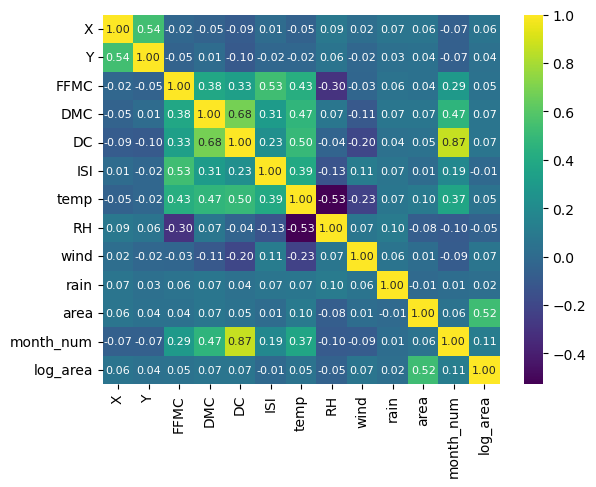

In [8]:
grafCorr = sns.heatmap(df.corr(),cmap="viridis",annot=True, fmt=".2f", annot_kws={"size": 8})

Tomando de referencia la columna de "log_area" (area quemada ya transformada con log(x+1)) ordenamos los valores de correlación existentes con las demás columnas para visualizar cuáles son las variables con mayor correlación con log_area.
Obviamos la columna de "area" ya que la transfomación con log(x+1) se realizó sobre esta misma.

In [9]:
df.corr()['log_area'].sort_values(ascending=False)

log_area     1.000000
area         0.524134
month_num    0.114280
DMC          0.067153
wind         0.066973
DC           0.066360
X            0.061995
temp         0.053487
FFMC         0.046799
Y            0.038838
rain         0.023311
ISI         -0.010347
RH          -0.053662
Name: log_area, dtype: float64

Dentro de esta correlación, obviando la columna de area, encontramos que no existe alguna correlación demasiado fuerte entre las columnas, buscamos números cercanos a 1, y el más cercano es month_num con valor de 0.11, seguido de DMC, wind y DC con un valor aprox 0.06 y temp con valor de 0.05.
Debido a que no encontramos una variable que esté fuertemente relacionada con "log_area", se procederá a realizar regresión lineal múltiple, y aunque la relación sea demasiado baja entre las variables y la variable objetivo se tomarán para realizar la regresión con el objetivo de explorar posibles combinaciones que, en conjunto, aporten un valor predictivo.  

Dada la explicación anterior, las variables a tomar en cuenta son **month_num**, **DMC**, **wind**, **DC** y **Temp** ya que decidimos que el umbral para seleccionar las variables deben superar el 0.05 ya que es un punto medio entre la variable con mayor correlación con la variable objetivo y el 0 absoluto.


Comenzaremos a seleccionar las columnas, además de redimensionarlos.
**DMC** es la columna 3, **DC** la columna 4, **Temp** la columna 6, **Wind** la columna 8 y finalmente **month_num** la columna 11.

In [10]:
x = df.iloc[:, [3, 4, 6, 8, 11]].to_numpy()
y = df['log_area'].to_numpy().reshape(-1, 1)
print(x.shape)
print(y.shape)

(517, 5)
(517, 1)


Dividiremos el dataset a porcentajes de 70% para entrenamiento y 30% para la predicción, y de esta manera comparar los datos que obtenemos y los que fueron registrados para verificar las predicciones e importaremos también el modelo de predicción.

In [11]:
from sklearn.model_selection import train_test_split
x_entren, x_prueba, y_entren, y_prueba = train_test_split(x, y, train_size=0.7, test_size=0.3, random_state=42)
from sklearn.linear_model import LinearRegression
mod_lin_multiple = LinearRegression()
mod_lin_multiple.fit(x_entren,y_entren)

LinearRegression()

Ahora imprimimos el intercepto y la beta de cada una de las variables para observarlos 

In [12]:
beta_0 = mod_lin_multiple.intercept_[0]
beta_dmc = mod_lin_multiple.coef_[0][0]
beta_dc = mod_lin_multiple.coef_[0][1]
beta_temp = mod_lin_multiple.coef_[0][2]
beta_wind = mod_lin_multiple.coef_[0][3]
beta_month_num = mod_lin_multiple.coef_[0][4]

print("Parámetros: ")
print(f"\tbeta_0:{beta_0}")
print(f"\tbeta_dmc:{beta_dmc}")
print(f"\tbeta_dc:{beta_dc}")
print(f"\tbeta_temp:{beta_temp}")
print(f"\tbeta_wind:{beta_wind}")
print(f"\tbeta_month_num:{beta_month_num}")

Parámetros: 
	beta_0:0.32059435648452106
	beta_dmc:0.0027954645324429575
	beta_dc:-0.0010709450725921324
	beta_temp:-0.0023381791785254684
	beta_wind:0.03314563750609034
	beta_month_num:0.13168540766722847


Desde las betas podemos confirmar que las variables que más impacto tienen para la predicción son el mes (num_month) y el viento (wind) aunque no parecen demasiado determinantes para la variable objetivo.

In [13]:
y_pred = mod_lin_multiple.predict(x_prueba)

Ahora se compararán los resultados de "y_pred" y los datos reales "y_prueba" con el coeficiente de determinación r², además del error absoluto medio y error cuadrático medio, lo cual nos dará información acerca del desempeño del modelo.

In [14]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

r2 = r2_score(y_prueba, y_pred)
print(f"R² Coeficiente de determinacion: {r2:.3f}")
mse = mean_squared_error(y_prueba, y_pred)
rmse = np.sqrt(mse)
print(f"RMSE Raíz de error cuadrático medio: {rmse:.3f}")
mae = mean_absolute_error(y_prueba, y_pred)
print(f"MAE Error Absoluto medio : {mae:.3f}")

R² Coeficiente de determinacion: 0.027
RMSE Raíz de error cuadrático medio: 1.375
MAE Error Absoluto medio : 1.124


La interpretación de cada uno de los errores es la siguiente

- Para R² mientras el resultado sea mas cercano a 1 es mejor para el modelo, en este caso es muy bajo, casi 0. En porcentaje podemos concluir que sólo se explica un 2.7% de la variabilidad total (casi nada).
- RMSE indica que la predicción del modelo se desvía **1.375** unidades de **log_area**
- MAE indica que la prediccion del modelo se desvía **1.124** unidades de **log_area**

RMSE y MAE indican los errores que existen dentro del modelo, RMSE penaliza errores en outliers y MAE trata los errores por igual, que sean casi parecidos muestran que los errores de predicción son uniformes aunque hay que resaltar que previamente realizamos la transformación con log(area+1) debido a la descripción del dataset. Pero que R² sea muy bajo indica que el modelo no logra encontrar la relación entre las variables y la variable objetivo.

Se graficarán los resultados de la predicción y se realizará la comparación con los valores reales, primero realizaremos la gráfica con los datos transformados a log(area+1) y después se aplicará la inversa a la transformación de log(area+1) para después graficar y observar el área en hectáreas.


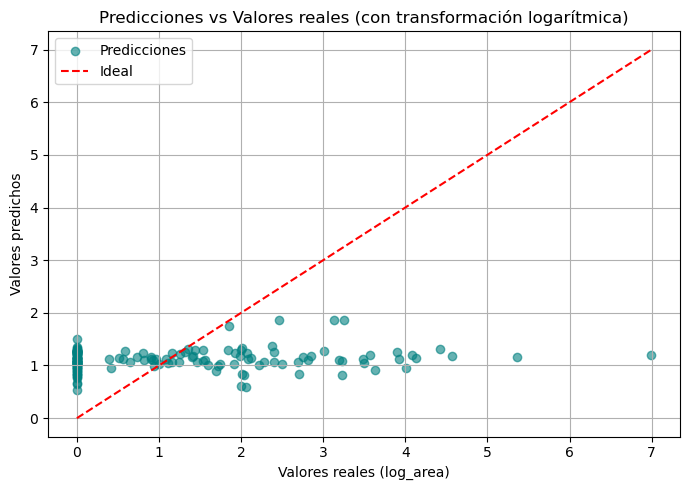

In [15]:
#Datos con log(area+1)
plt.figure(figsize=(7, 5))
plt.scatter(y_prueba, y_pred, alpha=0.6, color='teal', label='Predicciones')
plt.plot([y_prueba.min(), y_prueba.max()], [y_prueba.min(), y_prueba.max()], 'r--', label='Ideal')
plt.xlabel('Valores reales (log_area)')
plt.ylabel('Valores predichos')
plt.title('Predicciones vs Valores reales (con transformación logarítmica)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Con la escala logarítmica podemos observar más cerca los datos que fueron predichos.
Gracias a esta gráfica podemos empezar a concluir que el modelo no predice de manera precisa con las variables otorgadas a la variable objetivo, recordando que se trata de el área quemada resultante después del incendio, ya que desde el inicio notamos que la relación entre variables no era demasiado fuerte, por lo que se esperaban resultados así.
Se le puede otorgar crédito al modelo en la predicción de incendios en un pequeño intérvalo, ya que justamente en la escala logarítmica de aproximadamente 0.7 a 1.5 se observa que la predicción no se aleja demasiado de la recta ideal. 

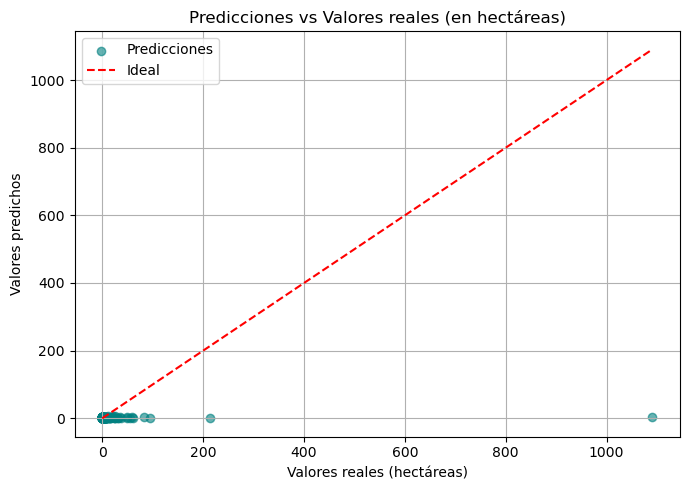

In [16]:
#Datos con la inversa exp(area)-1
y_prueba_real = np.exp(y_prueba) - 1
y_pred_real = np.exp(y_pred) - 1
plt.figure(figsize=(7, 5))
plt.scatter(y_prueba_real, y_pred_real, alpha=0.6, color='teal', label='Predicciones')
plt.plot([y_prueba_real.min(), y_prueba_real.max()], [y_prueba_real.min(), y_prueba_real.max()], 'r--', label='Ideal')
plt.xlabel('Valores reales (hectáreas)')
plt.ylabel('Valores predichos')
plt.title('Predicciones vs Valores reales (en hectáreas)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Finalmente, se realizarán comprobaciones para verificar que el modelo no se encuentre sesgado y no siga patrones de comportamiento (como subestimar o sobreestimar los datos), y que los errores sean constantes entre sí, para verificar que no existan errores de heterocesdasticidad, o sea, verificar que el modelo capture el patrón de los datos correctamente.
Aunque ya se observó que las predicciones no se encuentran demasiado cerca de los datos reales, debemos realizar la prueba para verificar que el modelo fue aplicado de manera correcta.
Realizaremos el promedio de la diferencia entre los valores reales y los predichos por el modelo, o sea, los residuos.

In [17]:
y_prueba = y_prueba.ravel()
y_pred = y_pred.ravel()
residuales = y_prueba - y_pred
#se realiza conversión de ambas matrices para evitar
#conflictos a futuro en gráficas

residuales = y_prueba - y_pred
media_residuos = np.mean(residuales)
print(f"Media de los residuos: {media_residuos:.4f}")
if np.isclose(media_residuos, 0, atol=1e-6):
    print("Los residuos están centrados en 0 (media ≈ 0)")
else:
    print("Los residuos no están centrados en 0 (media diferente de 0)")

Media de los residuos: -0.0204
Los residuos no están centrados en 0 (media diferente de 0)


Los residuos son casi 0, podemos decir que "sobreestima" los valores reales pero es demasiada baja la sobreestimación. No existe una tendencia sistemática a equivocarse en una dirección

Pero, si los residuos nos dicen que el modelo no tiene una tendencia a equivocarse en una dirección, ¿porqué en la gráfica con escala logarítmica nos muestra que la mayoría de las predicciones se encuentran arriba de la línea ideal? (sobre las coordenadas 0,1).

Primero hay que comprender qué es lo que se calcula, el dato anterior es un **promedio** de los residuos, esto indica que todos los datos se toman y se obtiene una media, la cual compensa los errores positivos con los negativos (y en otros casos viceversa)

Para evitar que tanto los valores extremos (outliers) de los residuos afecten el resultado del promedio y la naturaleza de la tendencia central escogida nos "oculte" el comportamiento de los residuos, podemos aplicar **la mediana** la cual no se ve afectada por los valores outliers ni por compensaciones entre sí de los datos y puede brindarnos más información.

In [18]:
print("Mediana de los residuos:", np.median(residuales))

Mediana de los residuos: -0.6309781592197374


Ahora obtuvimos un valor más alto, que indica que el modelo efectivamente sobreestima los resultados
Graficamos para poder observar los residuos que existen en nuestro modelo

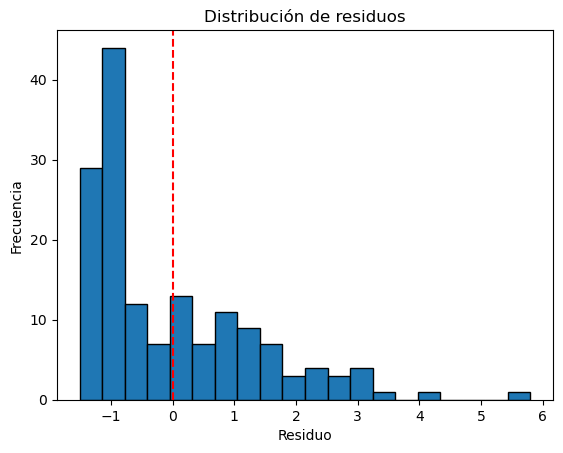

In [19]:
plt.hist(residuales, bins=20, edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribución de residuos')
plt.xlabel('Residuo')
plt.ylabel('Frecuencia')
plt.show()

Y de manera visual, confirmamos que los residuos se concentran de gran manera en la parte izquierda del 0, por lo que existe un sesgo a la derecha de los errores, confirmando la tendencia que vimos en las gráficas de predicción vs datos reales, pues el modelo sobreestima los datos predichos.
Dentro de la gráfica "Predicciones vs Valores reales (con transformación logarítmica)" observamos una "mancha azul" (la cual indica que demasiadas predicciones se encuentran ahí, a tal punto de mostrar un color sólido) sobre x=0 que se distribuye de y=0.5 a y=1.5 aproximadamente y más predicciones de encuentran arriba de la línea ideal hasta x=1, de ahí en adelante, observamos puntos dispersos debajo de la línea roja ideal.
Esto concuerda con nuestra gráfica de distribución de residuos ya que existen demasiados puntos arriba de la línea, que son los números negativos de los residuos, mostrando una tendencia a sobreestimar y corroborando la mediana calculada.
Y de subestimaciones sólo encontramos puntos dispersos, distribuidos desde x=1.3 aproximadamente hasta x=7, los cuales son los que compensan a los errores negativos dentro del promedio ya que, por ejemplo, el punto solitario de 7, se encuentra a 5.8 unidades del eje y (aproximadamente) de distancia de la línea ideal roja.

Ahora realizaremos una comparación entre residuos y predicciones, para observar cómo distan entre sí, y cómo se distribuyen.

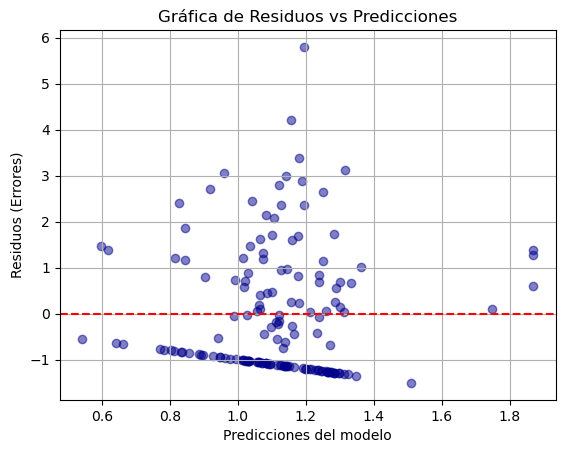

In [20]:
plt.scatter(y_pred, residuales, color='darkblue', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Gráfica de Residuos vs Predicciones')
plt.xlabel('Predicciones del modelo')
plt.ylabel('Residuos (Errores)')
plt.grid(True)
plt.show()

Finalmente realizaremos pruebas de Shapiro-Wilk y Kolmogorov-Smirnov, la primera para observar normalidad en residuos de regresión y la segunda para comparar los datos con una distribución teórica.

In [21]:
from scipy import stats

shapiro_stat, shapiro_p = stats.shapiro(residuales)
print("Shapiro-Wilk Test:")
print(f"Estadístico = {shapiro_stat:.4f}, p-valor = {shapiro_p:.4f}")
if shapiro_p < 0.05:
    print("Se rechaza H0: Los datos NO siguen una distribución normal.\n")
else:
    print("No se rechaza H0: Los datos podrían seguir una distribución normal.\n")


residuales_std = (residuales - np.mean(residuales)) / np.std(residuales)
ks_stat, ks_p = stats.kstest(residuales_std, 'norm')
print("Kolmogorov-Smirnov Test:")
print(f"Estadístico = {ks_stat:.4f}, p-valor = {ks_p:.4f}")
if ks_p < 0.05:
    print("Se rechaza H0: Los datos NO siguen una distribución normal.\n")
else:
    print("No se rechaza H0: Los datos podrían seguir una distribución normal.\n")



Shapiro-Wilk Test:
Estadístico = 0.8440, p-valor = 0.0000
Se rechaza H0: Los datos NO siguen una distribución normal.

Kolmogorov-Smirnov Test:
Estadístico = 0.1823, p-valor = 0.0001
Se rechaza H0: Los datos NO siguen una distribución normal.



Ambas pruebas indican que los residuos no siguen una distribución normal, ya que "p" es pequeño, por lo que la hipótesis nula se rechaza en las dos.

### **Conclusiones**

Las variables designadas del dataset no logran definir a la variable objetivo al utilizar un modelo de regresión lineal múltiple, pues no existe una correlación fuerte entre ellas. Esto se pudo vislumbrar desde la tabla de correlaciones entre todas las variables y "log_area", donde el vínculo más fuerte sólo llegaba a 0.11 unidades, y las variables restantes caían de manera abrupta a los 0.06 y 0.05.
Esto muestra una de las dificultades que se encuentran al utilizar modelos de regresión lineal, ya que se buscan correlaciones que se acerquen lo máximo posible a 1 y si no existen, la predicción no será lo suficientemente precisa.

Es por esta razón que se utilizó la regresión lineal múltiple, ya que al no existir una variable fuertemente ligada a la variable objetivo, se tiene que realizar un conjunto de variables (con las mayores correlaciones) las cuales en grupo puedan contribuir a las predicciones.

Además, fue importante realizar la transformación de la variable categórica "month" ya que, al revisar las correlaciones encontramos que era la variable con mayor correlación con la variable objetivo, lo que demuestra la importancia de analizar las variables categóricas que tengan posibilidad de convertirse a numéricas.

Una vez realizado el modelo, encontramos lo que se venía pensando, que no es preciso y en general son predicciones no útiles, esto principalmente por las correlaciones, pero notamos que el modelo es bueno para los incendios pequeños, pues en el rango logarítmico de x = 0.5 a x = 1.5 las predicciones no distan demasiado de la línea ideal (máx 0.5 unidades).
Lamentablemente es un número pequeño de predicciones las que pueden ser correctas, pues la gran mayoría se encuentran sobreestimados, es decir, el modelo les añade un valor mayor a lo que realmente valen.

Y lo anterior se pudo comprobar con la frecuencia de los residuos, donde los residuos con frecuencia alta se encontraban concentrados a la izquierda del cero, además confirmarmos también que, aunque eran pocos residuos a la derecha del 0, tenían valores altos lo cual provoca que el promedio nos indicara que no existía ningún sesgo a pesar de que visualmente en las gráficas era evidente.

Finalmente, se concluye que para este dataset **no es recomendable aplicar un modelo de regresión**, ya que no existen variables con una relación directa o "fuerte" con la variable objetivo, lo que provoca que las predicciones disten mucho de los datos reales. Que las variables del dataset logren explicar sólo un **2.7%** de la variabilidad de los resultados (porcentaje de R²) nos muestra que es casi igual como usar un promedio entre todas las áreas quemadas. Otros modelos que no utilicen correlación pueden ser de gran ayuda para explicar el área quemada después de incendios.